In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [3]:
df=pd.read_csv("netflix_titles.csv")
print(df)
print(df.shape)

     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

In [4]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


#**GENEL BAKIŞ ÖZET**

In [5]:
ozet = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "eksik_değer":df.isnull().sum(),
    "eksik_değer_yüzdesi":(df.isnull().mean()*100).round(2)
})

ozet

,dtype,n_unique,eksik_değer,eksik_değer_yüzdesi
show_id,object,8807,0,0.00
type,object,2,0,0.00
title,object,8807,0,0.00
director,object,4528,2634,29.91
cast,object,7692,825,9.37
country,object,748,831,9.44
date_added,object,1767,10,0.11
release_year,int64,74,0,0.00
rating,object,17,4,0.05
duration,object,220,3,0.03


In [7]:
print("tekrar eden satır:", df.duplicated().sum())

tekrar eden satır: 0


#**Betimsel İstatistik ve Güven Aralığı**

In [9]:
def ortalama_guven_araligi(seri, guven=0.95):
    veri = seri.dropna()
    n = len(veri)
    # Serbestlik derecesi (n - 1) en az 1 olmalıdır
    if n < 2:
        return (veri.mean() if n == 1 else None), None, None
    ortalama = veri.mean()
    sem = stats.sem(veri)  # Standart hata
    t_kritik = stats.t.ppf((1 + guven) / 2, df=n - 1)
    hata_payi = t_kritik * sem
    return ortalama, ortalama - hata_payi, ortalama + hata_payi

sayisal_sutunlar = df.select_dtypes(include=['number']).columns

# 4. Tablo çıktısı
print(f"{'Değişken':<20s} {'Ortalama':>12s} {'%95 Alt':>12s} {'%95 Üst':>12s}")
print("-" * 60)
for degisken in sayisal_sutunlar:
    ortalama, alt, ust = ortalama_guven_araligi(df[degisken])
    if ortalama is not None:
        print(f"{degisken:<20s} {ortalama:>12.2f} {alt:>12.2f} {ust:>12.2f}")

#

Değişken                 Ortalama      %95 Alt      %95 Üst
------------------------------------------------------------
release_year              2014.18      2014.00      2014.36


In [10]:
df['movie_duration_min'] = df[df['type'] == 'Movie']['duration'].str.extract(r'(\d+)').astype(float)
df['tv_season_count'] = df[df['type'] == 'TV Show']['duration'].str.extract(r'(\d+)').astype(float)

# 3. Sayısal sütunları seç
sayisal_sutunlar = df.select_dtypes(include=['number']).columns

# 4. Betimsel istatistikleri, çarpıklık (skewness) ve basıklık (kurtosis) değerlerini hesapla
betimsel = df[sayisal_sutunlar].describe().T
betimsel["skew"] = df[sayisal_sutunlar].skew()
betimsel["kurtosis"] = df[sayisal_sutunlar].kurtosis()

# 5. Sonucu iki basamağa yuvarlayarak yazdır
sonuc = betimsel.round(2)
print(sonuc)

                     count     mean    std     min     25%     50%     75%  \
release_year        8807.0  2014.18   8.82  1925.0  2013.0  2017.0  2019.0   
movie_duration_min  6128.0    99.58  28.29     3.0    87.0    98.0   114.0   
tv_season_count     2676.0     1.76   1.58     1.0     1.0     1.0     2.0   

                       max  skew  kurtosis  
release_year        2021.0 -3.45     16.23  
movie_duration_min   312.0  0.20      2.29  
tv_season_count       17.0  3.42     16.13  


#**NORMALLİK TESTLERİ**


In [11]:
df['movie_duration_min'] = df[df['type'] == 'Movie']['duration'].str.extract(r'(\d+)').astype(float)
df['tv_season_count'] = df[df['type'] == 'TV Show']['duration'].str.extract(r'(\d+)').astype(float)

sayisal_sutunlar = ['release_year', 'movie_duration_min', 'tv_season_count']

print(f"{'Değişken':<20s} {'Shapiro-Wilk p':>16s} {'DAgostino p':>14s}  Yorum")
print("-" * 80)

for col in sayisal_sutunlar:
    veri = df[col].dropna()

    # D'Agostino testi en az 8 gözlem gerektirir
    if len(veri) < 8:
        continue

    # Shapiro-Wilk için 5000 elemanlık örneklem
    ornek = veri.sample(min(len(veri), 5000), random_state=0)
    sw_stat, sw_p = stats.shapiro(ornek)
    da_stat, da_p = stats.normaltest(veri)

    yorum = "Normal dağılım sağlanıyor." if sw_p > 0.05 else "Normal dağılım sağlanmıyor."

    # p değerleri çok küçük çıktığı için bilimsel gösterim (.4e) tercih edildi
    print(f"{col:<20s} {sw_p:>16.4e} {da_p:>14.4e}  {yorum}")

Değişken               Shapiro-Wilk p    DAgostino p  Yorum
--------------------------------------------------------------------------------
release_year               6.3199e-74     0.0000e+00  Normal dağılım sağlanmıyor.
movie_duration_min         4.3850e-31     7.6212e-82  Normal dağılım sağlanmıyor.
tv_season_count            5.7175e-64     0.0000e+00  Normal dağılım sağlanmıyor.


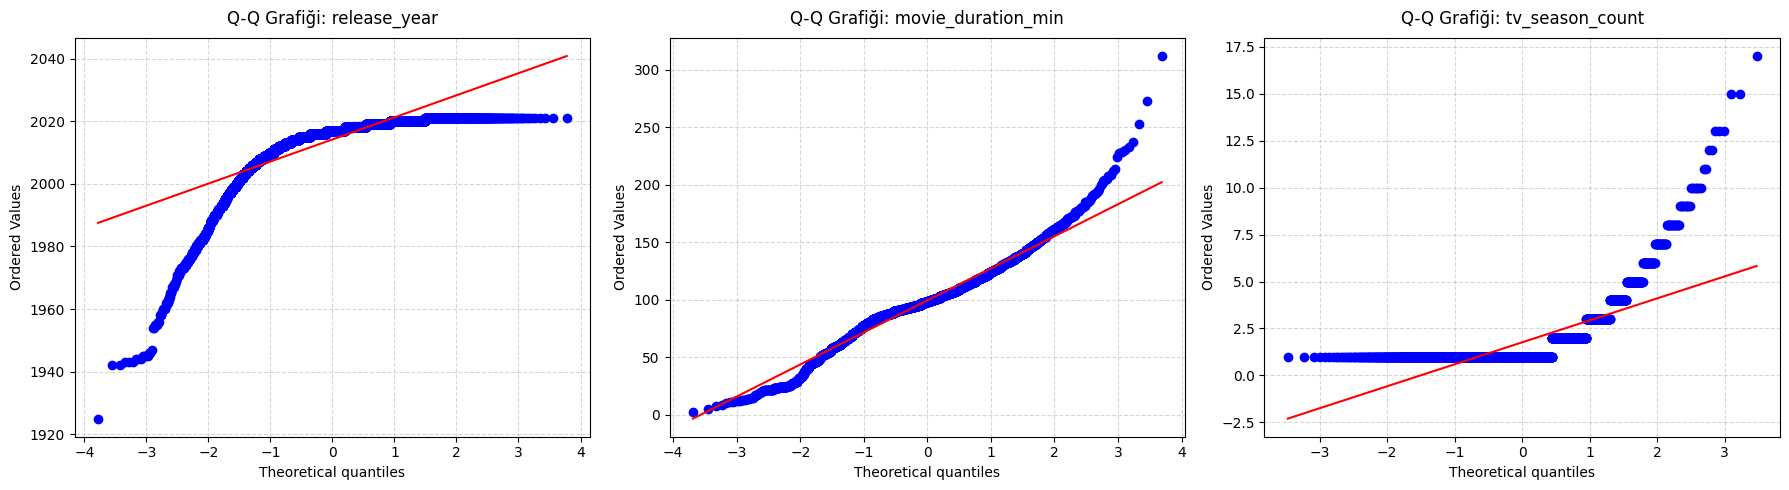

In [12]:
# Sayısal değişken listesi (film süresi ve sezon sayısı dahil)
sayisal_sutunlar = ['release_year', 'movie_duration_min', 'tv_season_count']

# Tek değişken kalma durumunda axes'in dizi olmasını garantiye alan yapı
fig, axes = plt.subplots(1, len(sayisal_sutunlar), figsize=(18, 5))
if len(sayisal_sutunlar) == 1:
    axes = [axes]

for ax, col in zip(axes, sayisal_sutunlar):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Grafiği: {col}", fontsize=12, pad=10)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#**İki Grup Karşılaştırması**

In [15]:
from scipy import stats

# Grupları 'type' sütununa göre ayırıp 'release_year' değerlerini alıyoruz
grup0 = df.loc[df["type"] == "Movie", "release_year"].dropna()
grup1 = df.loc[df["type"] == "TV Show", "release_year"].dropna()

# 1. Normallik Testi (Shapiro-Wilk)
n0 = min(len(grup0), 5000)
n1 = min(len(grup1), 5000)

_, p0 = stats.shapiro(grup0.sample(n0, random_state=0))
_, p1 = stats.shapiro(grup1.sample(n1, random_state=0))

normal_mi = (p0 > 0.05) and (p1 > 0.05)

print("Normallik Testi (Shapiro-Wilk):")
print(f" - Movie (Film): p = {p0:.4e} -> {'Normal' if p0 > 0.05 else 'Normal değil'}")
print(f" - TV Show (Dizi): p = {p1:.4e} -> {'Normal' if p1 > 0.05 else 'Normal değil'}")
print(f" Genel Dağılım Normalliği: {'Sağlandı' if normal_mi else 'Sağlanmadı'}\n")

# 2. Varyans Homojenliği Testi (Levene)
levene_stat, levene_p = stats.levene(grup0, grup1)
homojen_mi = levene_p > 0.05

print("Varyans Homojenliği (Levene):")
print(f" - İstatistik = {levene_stat:.4f}, p = {levene_p:.4e}")
print(f" Varyanslar: {'Homojendir (Eşit varyans)' if homojen_mi else 'Homojen değildir (Farklı varyans)'}\n")

# 3. Hangi Hipotez Testi Uygulanmalı?
print("Önerilen Hipotez Testi:")
if normal_mi:
    if homojen_mi:
        print("-> Bağımsız İki Örneklem T-Testi (Student's t-test)")
    else:
        print("-> Welch's T-Testi")
else:
    print("-> Mann-Whitney U Testi (Parametrik olmayan alternatif)")

Normallik Testi (Shapiro-Wilk):
 - Movie (Film): p = 7.8718e-72 -> Normal değil
 - TV Show (Dizi): p = 1.5899e-61 -> Normal değil
 Genel Dağılım Normalliği: Sağlanmadı

Varyans Homojenliği (Levene):
 - İstatistik = 171.8829, p = 6.6335e-39
 Varyanslar: Homojen değildir (Farklı varyans)

Önerilen Hipotez Testi:
-> Mann-Whitney U Testi (Parametrik olmayan alternatif)


# **çoklu grup karşılaştırması**

In [16]:
df = pd.read_csv("netflix_titles.csv")
df_movies = df[df["type"] == "Movie"].copy()

# 2. Metin halindeki süreyi ('90 min') sayısal dakikaya dönüştür
df_movies["duration_min"] = df_movies["duration"].str.extract(r"(\d+)").astype(float)

# 3. Yeterli gözlemi olan en yaygın yaş derecelendirmelerini (rating) seç
en_yaygin_ratingler = df_movies["rating"].value_counts().nlargest(4).index
df_analiz = df_movies[df_movies["rating"].isin(en_yaygin_ratingler)].dropna(subset=["duration_min"])

# 4. Grupları hazırla (her rating kategorisi için film süreleri listesi)
gruplar = [g["duration_min"].values for _, g in df_analiz.groupby("rating")]

# 5. Parametrik (Tek Yönlü ANOVA) ve Parametrik Olmayan (Kruskal-Wallis) Testleri
f_stat, anova_p = stats.f_oneway(*gruplar)
h_stat, kw_p = stats.kruskal(*gruplar)

# 6. Sonuçları yazdır
print("İncelenen Gruplar:", list(en_yaygin_ratingler))
print(f"Tek Yönlü ANOVA : F = {f_stat:.3f}, p = {anova_p:.4e}")
print(f"Kruskal-Wallis  : H = {h_stat:.3f}, p = {kw_p:.4e}")

if kw_p < 0.05:
    print("\nSonuç: Yaş derecelendirmelerine göre film süreleri arasında istatistiksel olarak anlamlı bir fark vardır.")
else:
    print("\nSonuç: Gruplar arasında istatistiksel olarak anlamlı bir fark bulunamamıştır.")

İncelenen Gruplar: ['TV-MA', 'TV-14', 'R', 'TV-PG']
Tek Yönlü ANOVA : F = 103.229, p = 9.0934e-65
Kruskal-Wallis  : H = 305.970, p = 5.0783e-66

Sonuç: Yaş derecelendirmelerine göre film süreleri arasında istatistiksel olarak anlamlı bir fark vardır.


In [17]:
tum_veriler = np.concatenate(gruplar)
genel_ortalama = tum_veriler.mean()

# Gruplar arası kareler toplamı (SS_between) ve toplam kareler toplamı (SS_total)
ss_between = sum(len(g) * (g.mean() - genel_ortalama)**2 for g in gruplar)
ss_total = sum((tum_veriler - genel_ortalama)**2)

# Etki büyüklüğü (Eta-kare)
eta_kare = ss_between / ss_total

# Yorumlama eşiği
if eta_kare < 0.06:
    etki_yorumu = "Küçük etki"
elif eta_kare < 0.14:
    etki_yorumu = "Orta düzey etki"
else:
    etki_yorumu = "Büyük etki"

print(f"Eta Kare: {eta_kare:.4f} ({etki_yorumu})")

Eta Kare: 0.0603 (Orta düzey etki)


In [18]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD testi: Bağımlı değişken (endog) süre, bağımsız grup (groups) yaş derecelendirmesi
tukey = pairwise_tukeyhsd(
    endog=df_analiz["duration_min"],
    groups=df_analiz["rating"],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     R  TV-14   3.5706 0.0132   0.5398   6.6014   True
     R  TV-MA -10.8303    0.0  -13.689  -7.9716   True
     R  TV-PG -11.8683    0.0 -15.6884  -8.0483   True
 TV-14  TV-MA -14.4009    0.0  -16.761 -12.0408   True
 TV-14  TV-PG  -15.439    0.0 -18.9017 -11.9762   True
 TV-MA  TV-PG  -1.0381  0.852  -4.3512   2.2751  False
------------------------------------------------------


## Kategorik Değişkenler Arasındaki İlişki


In [19]:
# En sık kullanılan 5 yaş derecelendirmesi
en_yaygin_ratingler = df["rating"].value_counts().nlargest(5).index
df_kategorik = df[df["rating"].isin(en_yaygin_ratingler)].dropna(subset=["type", "rating"])

def cramers_v(x, y):
    tablo = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tablo)[0]
    n = tablo.to_numpy().sum()
    k = min(tablo.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 and n > 0 else 0.0

capraz = pd.crosstab(df_kategorik["type"], df_kategorik["rating"])
chi2, p, dof, beklenen = stats.chi2_contingency(capraz)
v = cramers_v(df_kategorik["type"], df_kategorik["rating"])

print(f"chi2={chi2:.4f}, p={p:.4e}, v={v:.4f}")
print(f"Cramer's V: {v:.4f}")
print("\nÇapraz Tablo:")
print(capraz)

chi2=641.9716, p=1.2749e-137, v=0.2922
Cramer's V: 0.2922

Çapraz Tablo:
rating   PG-13    R  TV-14  TV-MA  TV-PG
type                                    
Movie      490  797   1427   2062    540
TV Show      0    2    733   1145    323


## **Korelasyon Analizi**



In [20]:
# Netflix için anlamlı sayısal sütunlar (film süresi ve platforma eklenme yılı)
df["movie_duration_min"] = df[df["type"] == "Movie"]["duration"].str.extract(r"(\d+)").astype(float)
df["added_year"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce").dt.year

sayisal_sutunlar = ["release_year", "movie_duration_min", "added_year"]

def korelasyon_p_matrisi(veri, yontem="pearson"):
    sutunlar = veri.columns
    n = len(sutunlar)

    # Köşegenler r=1.0 ve p=0.0 olacak şekilde birim matrisle başlatma
    kat = pd.DataFrame(np.eye(n), index=sutunlar, columns=sutunlar)
    pval = pd.DataFrame(np.zeros((n, n)), index=sutunlar, columns=sutunlar)

    # Simetrik olduğu için sadece üst üçgeni hesaplayıp karşı tarafa kopyalama (2 kat daha hızlı)
    for i in range(n):
        for j in range(i + 1, n):
            col_i, col_j = sutunlar[i], sutunlar[j]
            ortak = veri[[col_i, col_j]].dropna()

            if len(ortak) < 2:
                r, p = np.nan, np.nan
            else:
                test_fn = stats.pearsonr if yontem == "pearson" else stats.spearmanr
                r, p = test_fn(ortak.iloc[:, 0], ortak.iloc[:, 1])

            kat.loc[col_i, col_j] = kat.loc[col_j, col_i] = float(r)
            pval.loc[col_i, col_j] = pval.loc[col_j, col_i] = float(p)

    return kat, pval

pearson_r, pearson_p = korelasyon_p_matrisi(df[sayisal_sutunlar], "pearson")

print("--- Pearson Korelasyon Katsayıları (r) ---")
print(pearson_r.round(4))
print("\n--- Pearson p Değerleri ---")
print(pearson_p.round(4))

--- Pearson Korelasyon Katsayıları (r) ---
                    release_year  movie_duration_min  added_year
release_year              1.0000             -0.2063      0.1115
movie_duration_min       -0.2063              1.0000      0.1244
added_year                0.1115              0.1244      1.0000

--- Pearson p Değerleri ---
                    release_year  movie_duration_min  added_year
release_year                 0.0                 0.0         0.0
movie_duration_min           0.0                 0.0         0.0
added_year                   0.0                 0.0         0.0


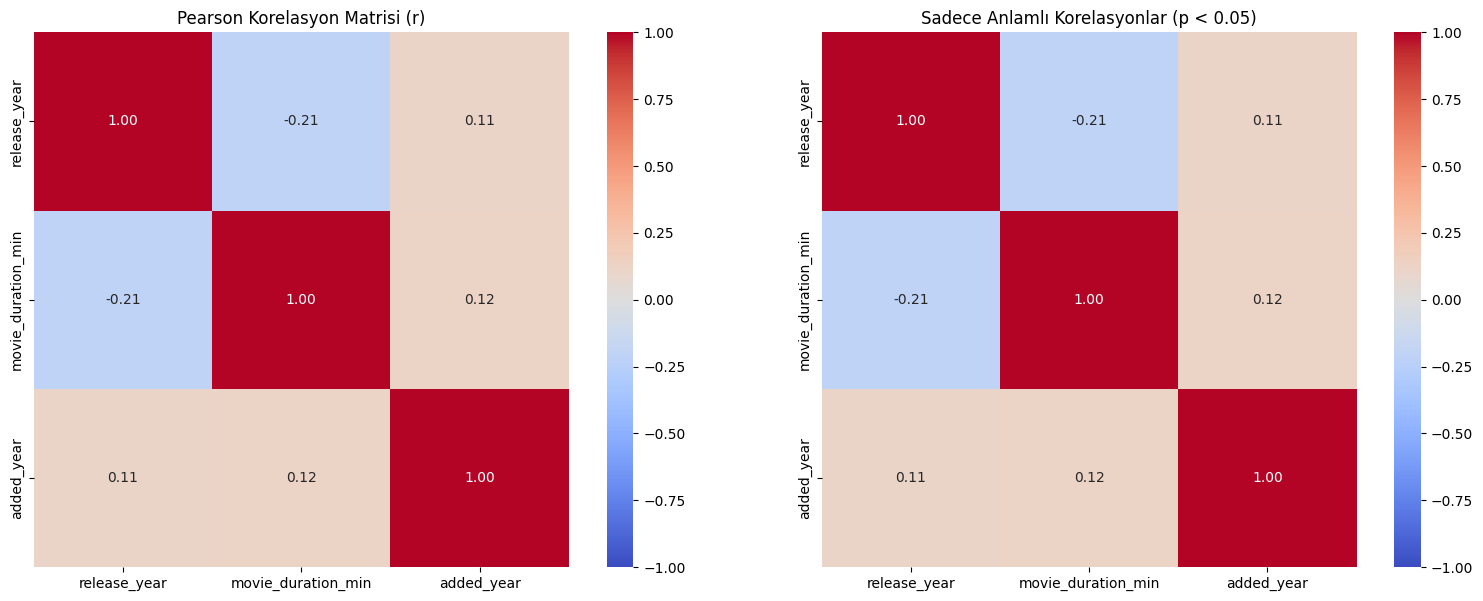

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Sol Grafik: Tüm Korelasyon Katsayıları (r)
sns.heatmap(
    pearson_r,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Pearson Korelasyon Matrisi (r)")

# 2. Sağ Grafik: Yalnızca İstatistiksel Olarak Anlamlı (p < 0.05) Korelasyonlar
# Seaborn'da 'mask=True' olan hücreler gizlenir; bu yüzden anlamlı olmayanlar (p >= 0.05) maskelenir
anlamsiz_maske = pearson_p >= 0.05

sns.heatmap(
    pearson_r,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    mask=anlamsiz_maske,
    square=True,
    ax=axes[1],
)
axes[1].set_title("Sadece Anlamlı Korelasyonlar (p < 0.05)")

plt.tight_layout()
plt.show()

## **Çoklu Doğrusal Bağlantı(Multicollinerity)**

In [22]:
# Netflix için sayısal değişkenler
df["movie_duration_min"] = df[df["type"] == "Movie"]["duration"].str.extract(r"(\d+)").astype(float)
df["added_year"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce").dt.year

# 1. Sayısal özellikleri seç ve eksik verileri temizle
X_vif = df[["release_year", "added_year", "movie_duration_min"]].dropna()

# 2. Sabit terim (constant) ekle
X_vif = sm.add_constant(X_vif)

# 3. VIF hesaplama tablosu (Sabit terim hariç tutulabilir veya hepsi gösterilebilir)
vif_tablosu = pd.DataFrame({
    "Değişken": X_vif.columns,
    "VIF": [VIF(X_vif.values, i) for i in range(X_vif.shape[1])]
})

# Sabit terimi (const) çıkarıp sadece bağımsız değişkenleri görmek istersen:
vif_ozet = vif_tablosu[vif_tablosu["Değişken"] != "const"].copy()
vif_ozet["VIF"] = vif_ozet["VIF"].round(2)
vif_ozet["Yorum"] = vif_ozet["VIF"].apply(
    lambda x: "Çoklu doğrusal bağlantı yok (Güvenli)" if x < 5 else ("Orta düzey korelasyon" if x < 10 else "Yüksek çoklu bağlantı (Multicollinearity)")
)

print(vif_ozet.to_string(index=False))

          Değişken  VIF                                 Yorum
      release_year 1.05 Çoklu doğrusal bağlantı yok (Güvenli)
        added_year 1.02 Çoklu doğrusal bağlantı yok (Güvenli)
movie_duration_min 1.06 Çoklu doğrusal bağlantı yok (Güvenli)


In [23]:
# Netflix sayısal özellikleri (film süresi ve eklenme yılı dahil)
df["movie_duration_min"] = df[df["type"] == "Movie"]["duration"].str.extract(r"(\d+)").astype(float)
df["added_year"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce").dt.year

# Eksik verileri temizleme ve sabit terim (const) ekleme
X_vif = df[["release_year", "added_year", "movie_duration_min"]].dropna()
X_vif_const = sm.add_constant(X_vif)

# 0. indeksteki sabiti (const) atlayıp 1'den başlatarak VIF hesaplama
vif_tablosu = pd.DataFrame({
    "Değişken": X_vif.columns,
    "VIF": [VIF(X_vif_const.values, i) for i in range(1, X_vif_const.shape[1])]
})

vif_tablosu["VIF"] = vif_tablosu["VIF"].round(2)
print(vif_tablosu)

             Değişken   VIF
0        release_year  1.05
1          added_year  1.02
2  movie_duration_min  1.06


In [24]:
# Netflix için sayısal değişkenler
df["movie_duration_min"] = df[df["type"] == "Movie"]["duration"].str.extract(r"(\d+)").astype(float)
df["added_year"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce").dt.year

# 1. Değişkenleri seç, boşlukları temizle ve sabit sütununu ekle
X_vif = df[["release_year", "added_year", "movie_duration_min"]].dropna()
X_vif = sm.add_constant(X_vif)

# 2. Hem sütun isimlerinde hem VIF hesaplamasında 0. indeksi (const) atlayıp 1'den başlat
vif_tablosu = pd.DataFrame({
    "Değişken": [X_vif.columns[i] for i in range(1, X_vif.shape[1])],
    "VIF": [VIF(X_vif.values, i) for i in range(1, X_vif.shape[1])]
})

vif_tablosu["VIF"] = vif_tablosu["VIF"].round(2)
print(vif_tablosu)

             Değişken   VIF
0        release_year  1.05
1          added_year  1.02
2  movie_duration_min  1.06
